In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import IsolationForest

In [6]:
# Step 1: Create a sample dataset
np.random.seed(42)
data = np.random.normal(loc=50, scale=5, size=100)
data = np.append(data, [100, 105, 110])  # add outliers

df = pd.DataFrame({'value': data})

In [8]:
df

,value
0,52.483571
1,49.308678
2,53.238443
3,57.615149
4,48.829233
...,...
98,50.025567
99,48.827064
100,100.000000
101,105.000000


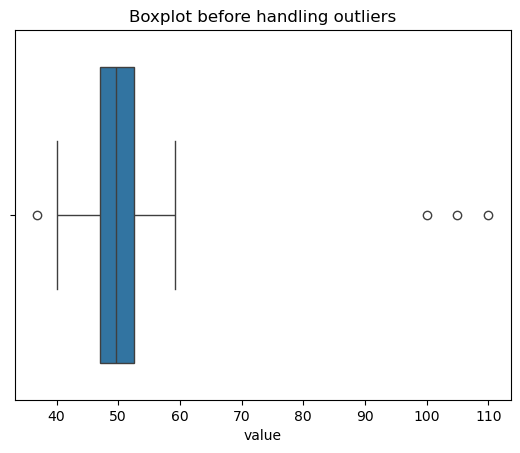

In [10]:
# Step 2: Visualize outliers
sns.boxplot(x=df['value'])
plt.title('Boxplot before handling outliers')
plt.show()

In [12]:
# Step 3: Detect using Z-score
df['z_score'] = np.abs(stats.zscore(df['value']))
outliers_z = df[df['z_score'] > 3]
print("Outliers using Z-score:\n", outliers_z)

Outliers using Z-score:
      value   z_score
100  100.0  4.717263
101  105.0  5.199579
102  110.0  5.681895


In [14]:
# Step 4: Detect using IQR
Q1 = df['value'].quantile(0.25)
Q3 = df['value'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers_iqr = df[(df['value'] < lower) | (df['value'] > upper)]
print("Outliers using IQR:\n", outliers_iqr)

Outliers using IQR:
           value   z_score
74    36.901274  1.369446
100  100.000000  4.717263
101  105.000000  5.199579
102  110.000000  5.681895


In [16]:
# Step 5: Handle Outliers (Remove)
df_cleaned = df[(df['value'] >= lower) & (df['value'] <= upper)]

In [18]:
# Step 6: Handle Outliers (Winsorization)
df['winsorized'] = stats.mstats.winsorize(df['value'], limits=[0.05, 0.05])

In [20]:
# Step 7: Handle Outliers (Log Transform)
df['log_transformed'] = np.log1p(df['value'])

In [22]:
# Step 8: Detect using Model (Isolation Forest)
clf = IsolationForest(contamination=0.05)
df['iforest_outlier'] = clf.fit_predict(df[['value']])
print("Outliers using Isolation Forest:\n", df[df['iforest_outlier'] == -1])

Outliers using Isolation Forest:
           value   z_score  winsorized  log_transformed  iforest_outlier
31    59.261391  0.787483   57.823218         4.098692               -1
74    36.901274  1.369446   41.375411         3.634985               -1
79    40.062155  1.064537   41.375411         3.715087               -1
100  100.000000  4.717263   57.823218         4.615121               -1
101  105.000000  5.199579   57.823218         4.663439               -1
102  110.000000  5.681895   57.823218         4.709530               -1


Text(0.5, 1.0, 'Boxplot after removing outliers')

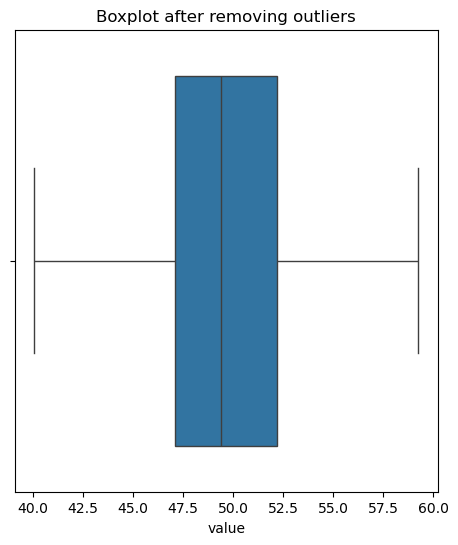

In [24]:
# Step 9: Visualize results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x=df_cleaned['value'])
plt.title('Boxplot after removing outliers')

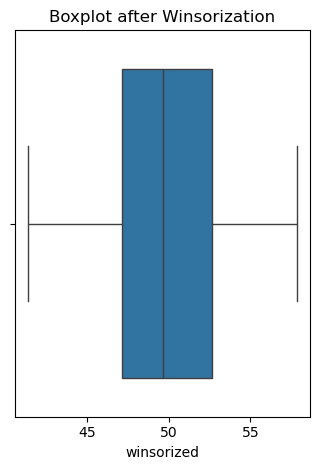

In [26]:
plt.subplot(1, 2, 2)
sns.boxplot(x=df['winsorized'])
plt.title('Boxplot after Winsorization')
plt.tight_layout()
plt.show()